# Event Display: Real Spill vs Synthetic Spill

This notebook displays one spill (tree entry) from one or more ROOTRacker files and compares it against a synthetic sample with the same number of particle entries.

Synthetic source options:
- Use pre-generated `synthetic_samples.parquet`
- Generate a fresh sample from a saved `generator.pth` checkpoint

## Notebook Plan

1. Load spill-level particle records from `RooTrackerTree` (one event entry = one spill).
2. Build a real-particle DataFrame (`x,y,z,px,py,pz,pdg,monitor_id`).
3. Build a synthetic DataFrame with exactly the same row count as the selected spill.
4. Convert synthetic feature-space columns to display-space cartesian coordinates.
5. Plot side-by-side event displays (3D and projections).
6. Print quick sanity checks (counts, ranges, feature availability).

In [11]:
import glob
import os
import sys
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awkward as ak
import uproot
import pyarrow.parquet as pq

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)

In [12]:
# ----------------------
# User configuration
# ----------------------
TRUTH_PARQUET = '/home/hep/jcc525/cleaned_data/pdgNone_monitor4.parquet'
SYNTHETIC_PARQUET = '/home/hep/jcc525/gan_particle_physics/gan_results/cwgan_full_filtered_2/synthetic_samples.parquet'
SPILL_SIZE_N = 200000
TRUTH_READ_ROWS = SPILL_SIZE_N   # only first N truth rows are read into memory
TRUTH_SAMPLE_MODE = 'random'   # 'random' | 'sequential'
TRUTH_SAMPLE_SEED = 42
SYNTH_SAMPLE_SEED = 123

# PDG filter options: None (all), single int (e.g. 13), or list (e.g. [13, -13, 11])
# PDG_FILTER = [13, -13, 211, -211]  # Example: only muons and anti-muons
# PDG_FILTER = [13]

# Optional manual PDG assignment for synthetic samples.
# Use None to preserve any existing synthetic `pdg` values.
# SYNTHETIC_PDG_OVERRIDE = 13

# Keep these for optional checkpoint generation path in this notebook
SYNTH_MODE = 'pregenerated'  # 'pregenerated' | 'checkpoint'
GAN_SRC_DIR = '/home/hep/jcc525/gan_particle_physics/src'
GAN_RUN_DIR = '/home/hep/jcc525/gan_particle_physics/gan_results/e_theta_constraint'
GENERATOR_CHECKPOINT = os.path.join(GAN_RUN_DIR, 'generator.pth')
TRAIN_PARQUET = '/home/hep/jcc525/cleaned_data/pdg13_monitor4.parquet'
DEVICE = 'cuda'

## Functions

In [13]:
def _read_first_n_parquet_rows(parquet_path: str, n_rows: int, batch_size: int = 65536) -> pd.DataFrame:
    n_rows = int(max(1, n_rows))
    parquet_file = pq.ParquetFile(parquet_path)

    chunks = []
    rows_read = 0
    for batch in parquet_file.iter_batches(batch_size=batch_size):
        if rows_read >= n_rows:
            break

        df_batch = batch.to_pandas()
        remaining = n_rows - rows_read
        if len(df_batch) > remaining:
            df_batch = df_batch.iloc[:remaining].copy()

        chunks.append(df_batch)
        rows_read += len(df_batch)

        if rows_read >= n_rows:
            break

    if not chunks:
        return pd.DataFrame()

    return pd.concat(chunks, ignore_index=True)


def _normalize_pdg_filter(pdg_filter):
    if pdg_filter is None:
        return None
    if isinstance(pdg_filter, (int, np.integer)):
        return {int(pdg_filter)}
    if isinstance(pdg_filter, (list, tuple, set, np.ndarray)):
        return {int(x) for x in pdg_filter}
    raise ValueError(f'Unsupported PDG filter type: {type(pdg_filter)}')


def _apply_pdg_filter(df: pd.DataFrame, pdg_filter=None) -> pd.DataFrame:
    if 'pdg' not in df.columns:
        return df

    pdg_set = _normalize_pdg_filter(pdg_filter)
    if pdg_set is None:
        return df

    out = df[df['pdg'].isin(pdg_set)].copy()
    return out.reset_index(drop=True)


def make_pseudo_spill(df: pd.DataFrame, n_rows: int, mode: str = 'random', seed: int = 42) -> pd.DataFrame:
    if len(df) == 0:
        raise ValueError('Input DataFrame is empty.')

    n_rows = int(max(1, n_rows))

    if mode == 'sequential':
        if len(df) <= n_rows:
            return df.reset_index(drop=True).copy()
        start_max = len(df) - n_rows
        start = int(np.random.default_rng(seed).integers(0, start_max + 1))
        return df.iloc[start:start + n_rows].reset_index(drop=True).copy()

    replace = len(df) < n_rows
    return df.sample(n=n_rows, replace=replace, random_state=seed).reset_index(drop=True).copy()


def load_truth_pseudo_spill(
    truth_parquet: str,
    n_rows: int,
    mode: str = 'random',
    seed: int = 42,
    read_rows: Optional[int] = None,
    pdg_filter=None,
) -> pd.DataFrame:
    n_rows = int(max(1, n_rows))
    read_rows = int(max(n_rows, read_rows if read_rows is not None else n_rows))

    truth_raw = _read_first_n_parquet_rows(truth_parquet, n_rows=read_rows)
    if len(truth_raw) == 0:
        raise ValueError(f'No rows read from truth parquet: {truth_parquet}')

    truth_raw = _apply_pdg_filter(truth_raw, pdg_filter=pdg_filter)
    if len(truth_raw) == 0:
        raise ValueError(f'No truth rows remain after PDG filter: {pdg_filter}')

    truth_disp = synthetic_features_to_display(truth_raw)
    truth_spill = make_pseudo_spill(truth_disp, n_rows=n_rows, mode=mode, seed=seed)
    return truth_spill


def describe_numeric_summary(df: pd.DataFrame, label: str) -> None:
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    print(f'--- {label} summary ---')
    print(f'Rows: {len(df):,}')
    print(f'Numeric columns: {len(numeric_cols)}')
    if numeric_cols:
        means = df[numeric_cols].mean(numeric_only=True)
        print('\nMeans:')
        print(means.to_string(float_format=lambda x: f'{x:.6f}'))

In [14]:
def synthetic_features_to_display(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if 'log1p_r' in out.columns and 'r' not in out.columns:
        out['r'] = np.expm1(out['log1p_r'])
    if 'log1p_p_mag' in out.columns and 'p_mag' not in out.columns:
        out['p_mag'] = np.expm1(out['log1p_p_mag'])

    if 'x' not in out.columns:
        out['x'] = 0.0

    if {'r', 'sin_phi_s', 'cos_phi_s'}.issubset(out.columns):
        out['y'] = out['r'] * out['cos_phi_s']
        out['z'] = out['r'] * out['sin_phi_s']
    else:
        if 'y' not in out.columns:
            out['y'] = np.nan
        if 'z' not in out.columns:
            out['z'] = np.nan

    if {'p_mag', 'sin_theta', 'cos_theta', 'phi_p'}.issubset(out.columns):
        transverse = out['p_mag'] * out['sin_theta']
        out['px'] = out['p_mag'] * out['cos_theta']
        out['py'] = transverse * np.cos(out['phi_p'])
        out['pz'] = transverse * np.sin(out['phi_p'])
    else:
        if 'px' not in out.columns:
            out['px'] = np.nan
        if 'py' not in out.columns:
            out['py'] = np.nan
        if 'pz' not in out.columns:
            out['pz'] = np.nan

    if 'pdg' not in out.columns:
        out['pdg'] = np.nan
    if 'monitor_id' not in out.columns:
        out['monitor_id'] = np.nan

    return out


def assign_synthetic_pdg(df: pd.DataFrame, pdg_override=None) -> pd.DataFrame:
    if pdg_override is None:
        return df

    out = df.copy()
    out['pdg'] = int(pdg_override)
    return out


def load_pregenerated_synthetic(path: str, n_rows: int, seed: int = 42, pdg_filter=None, pdg_override=None) -> pd.DataFrame:
    synth = pd.read_parquet(path)
    if len(synth) == 0:
        raise ValueError(f'Synthetic parquet is empty: {path}')

    synth = assign_synthetic_pdg(synth, pdg_override=pdg_override)
    synth = _apply_pdg_filter(synth, pdg_filter=pdg_filter)
    if len(synth) == 0:
        raise ValueError(f'No synthetic rows remain after PDG filter: {pdg_filter}')

    replace = len(synth) < n_rows
    synth = synth.sample(n=n_rows, replace=replace, random_state=seed).reset_index(drop=True)
    return synthetic_features_to_display(synth)

In [15]:
def generate_synthetic_from_checkpoint(n_rows: int, pdg_override=None) -> pd.DataFrame:
    import torch

    if GAN_SRC_DIR not in sys.path:
        sys.path.insert(0, GAN_SRC_DIR)

    from evaluate_saved_generator import (
        _infer_generator_architecture,
        _create_generator,
        _generate_synthetic_samples,
        _compute_normalization_stats,
    )
    from data_loader import load_preprocessed_data

    device = DEVICE if (DEVICE == 'cpu' or torch.cuda.is_available()) else 'cpu'
    state_dict = torch.load(GENERATOR_CHECKPOINT, map_location='cpu')
    inferred = _infer_generator_architecture(state_dict)

    train_df = load_preprocessed_data(TRAIN_PARQUET)
    model_type = 'wgan-gp' if inferred.get('normalization') == 'layernorm' else 'gan'
    mean, std = _compute_normalization_stats(train_df, model_type=model_type)

    generator = _create_generator(
        model_type=model_type,
        latent_dim=int(inferred['latent_dim']),
        output_dim=int(inferred['output_dim']),
        hidden_dims=list(inferred['hidden_dims']),
        normalization=str(inferred['normalization']),
    ).to(device)
    generator.load_state_dict(state_dict, strict=True)

    synth_np = _generate_synthetic_samples(
        generator=generator,
        n_samples=n_rows,
        latent_dim=int(inferred['latent_dim']),
        mean=mean,
        std=std,
        device=device,
        batch_size=8192,
        feature_names=list(train_df.columns),
        apply_angle_clipping=(model_type == 'wgan-gp'),
    )

    synth_df = pd.DataFrame(synth_np, columns=train_df.columns)
    synth_df = assign_synthetic_pdg(synth_df, pdg_override=pdg_override)
    return synthetic_features_to_display(synth_df)

In [16]:
def _shared_numeric_columns(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> list[str]:
    shared = [c for c in real_df.columns if c in synth_df.columns]
    numeric = [c for c in shared if pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])]
    return numeric


def print_variable_means_before_plot(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> None:
    cols = _shared_numeric_columns(real_df, synth_df)
    if not cols:
        print('No shared numeric columns to summarize.')
        return

    mean_df = pd.DataFrame({
        'real_mean': real_df[cols].mean(numeric_only=True),
        'synthetic_mean': synth_df[cols].mean(numeric_only=True),
    })
    mean_df['abs_diff'] = (mean_df['real_mean'] - mean_df['synthetic_mean']).abs()
    mean_df = mean_df.sort_index()

    print('\n--- Means of all shared numeric variables (before plotting) ---')
    print(mean_df.to_string(float_format=lambda x: f'{x:.6f}'))


def _ensure_xyz(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if 'x' not in out.columns:
        out['x'] = 0.0

    has_yz = ('y' in out.columns) and ('z' in out.columns)
    if not has_yz and {'r', 'sin_phi_s', 'cos_phi_s'}.issubset(out.columns):
        out['y'] = out['r'] * out['cos_phi_s']
        out['z'] = out['r'] * out['sin_phi_s']

    if 'y' not in out.columns:
        out['y'] = np.nan
    if 'z' not in out.columns:
        out['z'] = np.nan

    return out


def _downsample(df: pd.DataFrame, max_points: int, seed: int = 42) -> pd.DataFrame:
    if len(df) <= max_points:
        return df
    return df.sample(n=max_points, random_state=seed).reset_index(drop=True)


def _annotate_count_2d(ax, count: int, label: str = 'n'):
    ax.text(
        0.98,
        0.98,
        f'{label}={count:,}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
    )


def _annotate_count_3d(ax, count: int, label: str = 'n'):
    ax.text2D(
        0.98,
        0.98,
        f'{label}={count:,}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
    )


def _finite_min_max(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    return float(arr.min()), float(arr.max())


def _shared_axis_limits(real_df: pd.DataFrame, synth_df: pd.DataFrame, columns: list[str]) -> dict[str, tuple[float, float]]:
    limits: dict[str, tuple[float, float]] = {}
    for col in columns:
        r = _finite_min_max(real_df[col].to_numpy()) if col in real_df.columns else None
        s = _finite_min_max(synth_df[col].to_numpy()) if col in synth_df.columns else None
        candidates = [x for x in (r, s) if x is not None]
        if not candidates:
            continue
        lo = min(v[0] for v in candidates)
        hi = max(v[1] for v in candidates)
        if np.isclose(lo, hi):
            pad = 1.0 if np.isclose(lo, 0.0) else abs(lo) * 0.05
            lo -= pad
            hi += pad
        limits[col] = (lo, hi)
    return limits


def _normalize_pdg(value):
    if pd.isna(value):
        return 'unknown'
    try:
        return int(value)
    except Exception:
        return 'unknown'


def _build_pdg_color_map(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> dict:
    pdg_series = []
    if 'pdg' in real_df.columns:
        pdg_series.append(real_df['pdg'])
    if 'pdg' in synth_df.columns:
        pdg_series.append(synth_df['pdg'])

    if not pdg_series:
        return {'unknown': (0.55, 0.55, 0.55)}

    combined = pd.concat(pdg_series, ignore_index=True).map(_normalize_pdg)
    unique_pdgs = sorted([v for v in combined.unique() if v != 'unknown'])

    color_map = {'unknown': (0.55, 0.55, 0.55)}
    if unique_pdgs:
        palette = sns.color_palette('tab20', n_colors=len(unique_pdgs))
        for i, pdg in enumerate(unique_pdgs):
            color_map[pdg] = palette[i]
    return color_map


def _pdg_colors_for_df(df: pd.DataFrame, color_map: dict):
    if 'pdg' not in df.columns:
        keys = pd.Series(['unknown'] * len(df), index=df.index)
    else:
        keys = df['pdg'].map(_normalize_pdg)
    colors = keys.map(lambda k: color_map.get(k, color_map['unknown']))
    return colors, keys


def plot_3d_event_display(real_df: pd.DataFrame, synth_df: pd.DataFrame, max_points: int = 30000):
    from matplotlib.lines import Line2D

    real_base = _ensure_xyz(real_df)
    synth_base = _ensure_xyz(synth_df)

    real_cols = ['x', 'y', 'z'] + (['pdg'] if 'pdg' in real_base.columns else [])
    synth_cols = ['x', 'y', 'z'] + (['pdg'] if 'pdg' in synth_base.columns else [])

    real_xyz = _downsample(real_base[real_cols], max_points=max_points, seed=42)
    synth_xyz = _downsample(synth_base[synth_cols], max_points=max_points, seed=123)

    color_map = _build_pdg_color_map(real_base, synth_base)
    real_colors, real_keys = _pdg_colors_for_df(real_xyz, color_map)
    synth_colors, synth_keys = _pdg_colors_for_df(synth_xyz, color_map)

    fig = plt.figure(figsize=(20, 7))

    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(real_xyz['z'], real_xyz['x'], real_xyz['y'], s=1.2, alpha=0.22, c=list(real_colors))
    ax1.set_title(f'Real 3D (sampled n={len(real_xyz):,})')
    ax1.set_xlabel('z')
    ax1.set_ylabel('x')
    ax1.set_zlabel('y')
    _annotate_count_3d(ax1, len(real_xyz))

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(synth_xyz['z'], synth_xyz['x'], synth_xyz['y'], s=1.2, alpha=0.22, c=list(synth_colors))
    ax2.set_title(f'Synthetic 3D (sampled n={len(synth_xyz):,})')
    ax2.set_xlabel('z')
    ax2.set_ylabel('x')
    ax2.set_zlabel('y')
    _annotate_count_3d(ax2, len(synth_xyz))

    xyz_limits = _shared_axis_limits(real_xyz, synth_xyz, ['x', 'y', 'z'])
    if all(k in xyz_limits for k in ['x', 'y', 'z']):
        z_lim = xyz_limits['z']
        x_lim = xyz_limits['x']
        y_lim = xyz_limits['y']

        ax1.set_xlim(z_lim)
        ax1.set_ylim(x_lim)
        ax1.set_zlim(y_lim)
        ax2.set_xlim(z_lim)
        ax2.set_ylim(x_lim)
        ax2.set_zlim(y_lim)

        span_z = max(z_lim[1] - z_lim[0], 1e-9)
        span_x = max(x_lim[1] - x_lim[0], 1e-9)
        span_y = max(y_lim[1] - y_lim[0], 1e-9)
        ax1.set_box_aspect([span_z, span_x, span_y])
        ax2.set_box_aspect([span_z, span_x, span_y])

    legend_keys = sorted([k for k in color_map.keys() if k != 'unknown'])
    has_unknown = ('unknown' in set(real_keys)) or ('unknown' in set(synth_keys))
    if has_unknown:
        legend_keys.append('unknown')

    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[k], markersize=7, label=f'pdg={k}' if k != 'unknown' else 'pdg=unknown')
        for k in legend_keys
    ]
    if legend_handles:
        fig.legend(handles=legend_handles, loc='center left', bbox_to_anchor=(0.99, 0.5), frameon=True)

    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()


def plot_cylindrical_views(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    projection_pairs = [
        ('x', 'r'),
        ('sin_phi_s', 'cos_phi_s'),
        ('sin_theta', 'cos_theta'),
    ]

    for i, (xv, yv) in enumerate(projection_pairs):
        pair_limits = _shared_axis_limits(real_df, synth_df, [xv, yv])
        if xv in real_df.columns and yv in real_df.columns:
            sns.scatterplot(data=real_df, x=xv, y=yv, s=4, alpha=0.25, ax=axes[0, i], color='tab:blue', edgecolor=None)
            axes[0, i].set_title(f'Real: {xv} vs {yv}')
            _annotate_count_2d(axes[0, i], len(real_df))
        else:
            axes[0, i].text(0.5, 0.5, f'Missing columns:\n{xv}, {yv}', ha='center', va='center')
            axes[0, i].set_title('Real (unavailable)')

        if xv in synth_df.columns and yv in synth_df.columns:
            sns.scatterplot(data=synth_df, x=xv, y=yv, s=4, alpha=0.25, ax=axes[1, i], color='tab:orange', edgecolor=None)
            axes[1, i].set_title(f'Synthetic: {xv} vs {yv}')
            _annotate_count_2d(axes[1, i], len(synth_df))
        else:
            axes[1, i].text(0.5, 0.5, f'Missing columns:\n{xv}, {yv}', ha='center', va='center')
            axes[1, i].set_title('Synthetic (unavailable)')

        if xv in pair_limits:
            axes[0, i].set_xlim(pair_limits[xv])
            axes[1, i].set_xlim(pair_limits[xv])
        if yv in pair_limits:
            axes[0, i].set_ylim(pair_limits[yv])
            axes[1, i].set_ylim(pair_limits[yv])

    plt.tight_layout()
    plt.show()


def plot_cylindrical_marginals(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    preferred = ['x', 'r', 'sin_phi_s', 'cos_phi_s', 'sin_theta', 'cos_theta', 'phi_p', 'log_t', 'log1p_p_mag', 'log1p_r', 'p_mag']
    cols = [c for c in preferred if c in real_df.columns and c in synth_df.columns]

    if not cols:
        print('No shared cylindrical variables available for marginal plots.')
        return

    n_cols = 3
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.histplot(real_df[col], bins=80, stat='density', color='tab:blue', alpha=0.35, label='real', ax=ax)
        sns.histplot(synth_df[col], bins=80, stat='density', color='tab:orange', alpha=0.35, label='synthetic', ax=ax)
        ax.set_title(col)
        ax.legend()
        _annotate_count_2d(ax, len(real_df), label='n_real')
        ax.text(
            0.98,
            0.88,
            f'n_synth={len(synth_df):,}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
        )

    for j in range(len(cols), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


def plot_correlation_matrices(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    preferred = ['x', 'r', 'sin_phi_s', 'cos_phi_s', 'sin_theta', 'cos_theta', 'phi_p', 'log_t', 'log1p_p_mag', 'log1p_r', 'p_mag']
    cols = [c for c in preferred if c in real_df.columns and c in synth_df.columns]
    if len(cols) < 2:
        print('Not enough shared variables for correlation matrices.')
        return

    corr_real = real_df[cols].corr(numeric_only=True)
    corr_synth = synth_df[cols].corr(numeric_only=True)
    corr_diff = (corr_real - corr_synth).abs()

    fig, axes = plt.subplots(1, 3, figsize=(26, 8))

    sns.heatmap(
        corr_real,
        ax=axes[0],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[0].set_title('Real correlation matrix')

    sns.heatmap(
        corr_synth,
        ax=axes[1],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[1].set_title('Synthetic correlation matrix')

    sns.heatmap(
        corr_diff,
        ax=axes[2],
        cmap='magma',
        vmin=0,
        vmax=1,
        center=None,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[2].set_title('|Real - Synthetic| correlation difference')

    plt.tight_layout()
    plt.show()

## Outputs

In [17]:
if not os.path.exists(TRUTH_PARQUET):
    raise FileNotFoundError(f'Truth parquet not found: {TRUTH_PARQUET}')

if SYNTH_MODE == 'pregenerated':
    if not os.path.exists(SYNTHETIC_PARQUET):
        raise FileNotFoundError(f'Synthetic parquet not found: {SYNTHETIC_PARQUET}')
elif SYNTH_MODE == 'checkpoint':
    if not os.path.exists(GENERATOR_CHECKPOINT):
        raise FileNotFoundError(f'Generator checkpoint not found: {GENERATOR_CHECKPOINT}')
else:
    raise ValueError(f'Unsupported SYNTH_MODE: {SYNTH_MODE}')

real_spill_df = load_truth_pseudo_spill(
    truth_parquet=TRUTH_PARQUET,
    n_rows=SPILL_SIZE_N,
    mode=TRUTH_SAMPLE_MODE,
    seed=TRUTH_SAMPLE_SEED,
    read_rows=TRUTH_READ_ROWS,
    pdg_filter=PDG_FILTER,
)

print('Using truth source:')
print(f'  {TRUTH_PARQUET}')
print(f'Pseudo-spill size (n): {SPILL_SIZE_N:,}')
print(f'Truth read limit (first N rows): {TRUTH_READ_ROWS:,}')
print(f'Truth sampling mode: {TRUTH_SAMPLE_MODE}')
print(f'PDG filter: {PDG_FILTER}')

describe_numeric_summary(real_spill_df, label='Real (truth parquet pseudo-spill)')
real_spill_df.head()

Using truth source:
  /home/hep/jcc525/cleaned_data/pdgNone_monitor4.parquet
Pseudo-spill size (n): 200,000
Truth read limit (first N rows): 200,000
Truth sampling mode: random
PDG filter: [13]
--- Real (truth parquet pseudo-spill) summary ---
Rows: 200,000
Numeric columns: 16

Means:
pdg           13.000000
log_t          4.852635
x             -0.040000
r             65.904177
sin_phi_s      0.021064
cos_phi_s     -0.123708
p_mag         70.852924
sin_theta      0.920397
cos_theta      0.013016
phi_p          1.561239
y            -11.957650
z              0.519179
px             1.067417
py             0.269782
pz            60.413989
monitor_id          NaN


,pdg,log_t,x,r,sin_phi_s,cos_phi_s,p_mag,sin_theta,cos_theta,phi_p,y,z,px,py,pz,monitor_id
0,13,4.915482,-0.04,25.936365,0.402209,-0.915548,86.239053,0.991181,0.132513,1.330822,-23.745989,10.431829,11.427763,20.316348,83.029070,NaN
1,13,4.822034,-0.04,4.129101,-0.110298,0.993899,65.316800,0.992478,-0.122427,0.823411,4.103908,-0.455430,-7.996512,44.063353,47.547461,NaN
2,13,4.835846,-0.04,45.308095,0.943008,0.332769,68.545443,0.723480,0.690345,1.771404,15.077116,42.725917,47.320037,-9.881803,48.596726,NaN
3,13,4.927121,-0.04,45.983265,0.838783,0.544466,88.742639,0.998278,0.058666,2.061570,25.036304,38.569991,5.206169,-41.753141,78.133393,NaN
4,13,4.741869,-0.04,13.820470,0.591362,0.806406,44.503185,0.886509,0.462712,1.976770,11.144912,8.172902,20.592160,-15.580303,36.245698,NaN


In [18]:
n_particles = len(real_spill_df)

if SYNTH_MODE == 'pregenerated':
    synth_spill_df = load_pregenerated_synthetic(
        SYNTHETIC_PARQUET,
        n_rows=n_particles,
        seed=SYNTH_SAMPLE_SEED,
        pdg_filter=PDG_FILTER,
        pdg_override=SYNTHETIC_PDG_OVERRIDE,
    )
elif SYNTH_MODE == 'checkpoint':
    synth_spill_df = generate_synthetic_from_checkpoint(
        n_rows=n_particles,
        pdg_override=SYNTHETIC_PDG_OVERRIDE,
    )
    synth_spill_df = _apply_pdg_filter(synth_spill_df, pdg_filter=PDG_FILTER)
else:
    raise ValueError(f'Unsupported SYNTH_MODE: {SYNTH_MODE}')

print('Using synthetic source:')
if SYNTH_MODE == 'pregenerated':
    print(f'  {SYNTHETIC_PARQUET}')
else:
    print(f'  checkpoint: {GENERATOR_CHECKPOINT}')
print(f'Synthetic mode: {SYNTH_MODE}')
print(f'Synthetic pseudo-spill size (n): {len(synth_spill_df):,}')
print(f'PDG filter: {PDG_FILTER}')
print(f'Synthetic PDG override: {SYNTHETIC_PDG_OVERRIDE}')

describe_numeric_summary(synth_spill_df, label='Synthetic (generated parquet pseudo-spill)')
synth_spill_df.head()

Using synthetic source:
  /home/hep/jcc525/gan_particle_physics/gan_results/cwgan_full_filtered_2/synthetic_samples.parquet
Synthetic mode: pregenerated
Synthetic pseudo-spill size (n): 200,000
PDG filter: [13]
Synthetic PDG override: 13
--- Synthetic (generated parquet pseudo-spill) summary ---
Rows: 200,000
Numeric columns: 18

Means:
pdg           13.000000
log_t          3.492315
sin_phi_s     -0.043108
cos_phi_s      0.190832
sin_theta      0.912590
cos_theta      0.006968
phi_p          1.570902
log1p_p_mag    3.351924
log1p_r        4.161094
r             72.340958
p_mag         45.080685
x              0.000000
y             14.872000
z             -4.712416
px             0.395986
py             0.034209
pz            38.203243
monitor_id          NaN


,pdg,log_t,sin_phi_s,cos_phi_s,sin_theta,cos_theta,phi_p,log1p_p_mag,log1p_r,r,p_mag,x,y,z,px,py,pz,monitor_id
0,13,3.497420,-0.157911,0.987453,0.786713,-0.617320,1.944295,3.553774,3.639172,37.060295,33.944954,0.0,36.595314,-5.852226,-20.954885,-9.743956,24.863791,NaN
1,13,1.611723,-0.908447,0.418000,0.992644,0.121067,1.833393,1.806009,4.273292,70.757477,5.086108,0.0,29.576603,-64.279434,0.615759,-1.310586,4.875623,NaN
2,13,3.248573,-0.953709,-0.300730,0.737153,-0.675726,1.310611,3.304758,4.478456,87.098549,26.241938,0.0,-26.193161,-83.066689,-17.732365,4.976503,18.693233,NaN
3,13,4.854988,-0.913073,0.407796,0.883708,0.468039,1.728603,4.314314,3.195873,23.431488,73.762314,0.0,9.555264,-21.394661,34.523674,-10.243888,64.374359,NaN
4,13,3.973732,-0.302295,-0.953214,0.976380,0.216060,1.181788,3.997256,1.474918,3.370679,53.448528,0.0,-3.212980,-1.018939,11.548068,19.792671,48.287033,NaN



--- Means of all shared numeric variables (before plotting) ---
            real_mean  synthetic_mean  abs_diff
cos_phi_s   -0.123708        0.190832  0.314540
cos_theta    0.013016        0.006968  0.006048
log_t        4.852635        3.492315  1.360320
monitor_id        NaN             NaN       NaN
p_mag       70.852924       45.080685 25.772239
pdg         13.000000       13.000000  0.000000
phi_p        1.561239        1.570902  0.009663
px           1.067417        0.395986  0.671431
py           0.269782        0.034209  0.235573
pz          60.413989       38.203243 22.210746
r           65.904177       72.340958  6.436781
sin_phi_s    0.021064       -0.043108  0.064171
sin_theta    0.920397        0.912590  0.007807
x           -0.040000        0.000000  0.040000
y          -11.957650       14.872000 26.829649
z            0.519179       -4.712416  5.231594


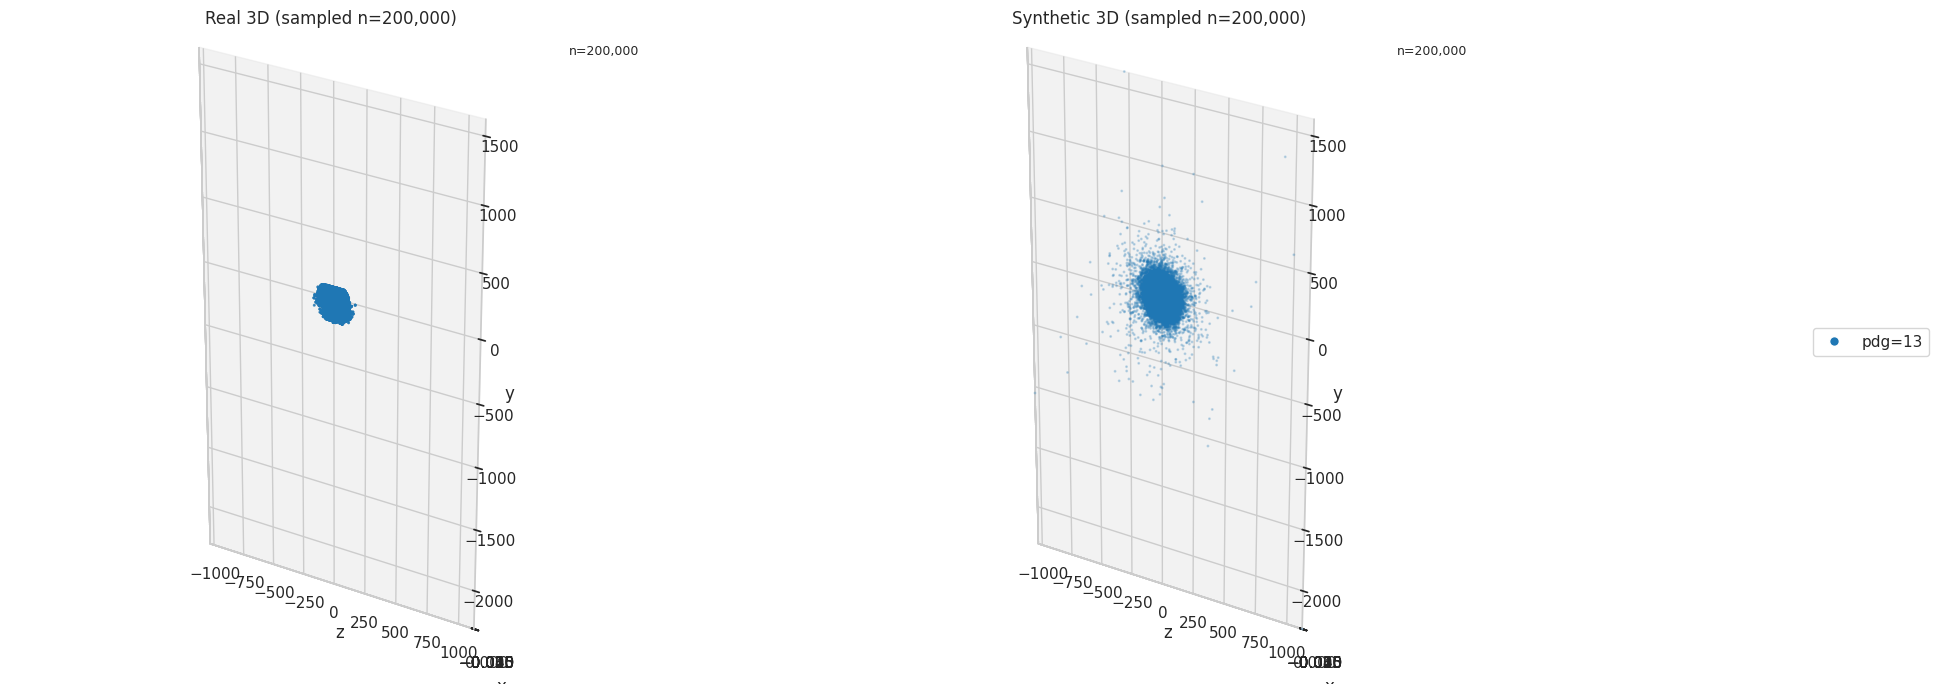

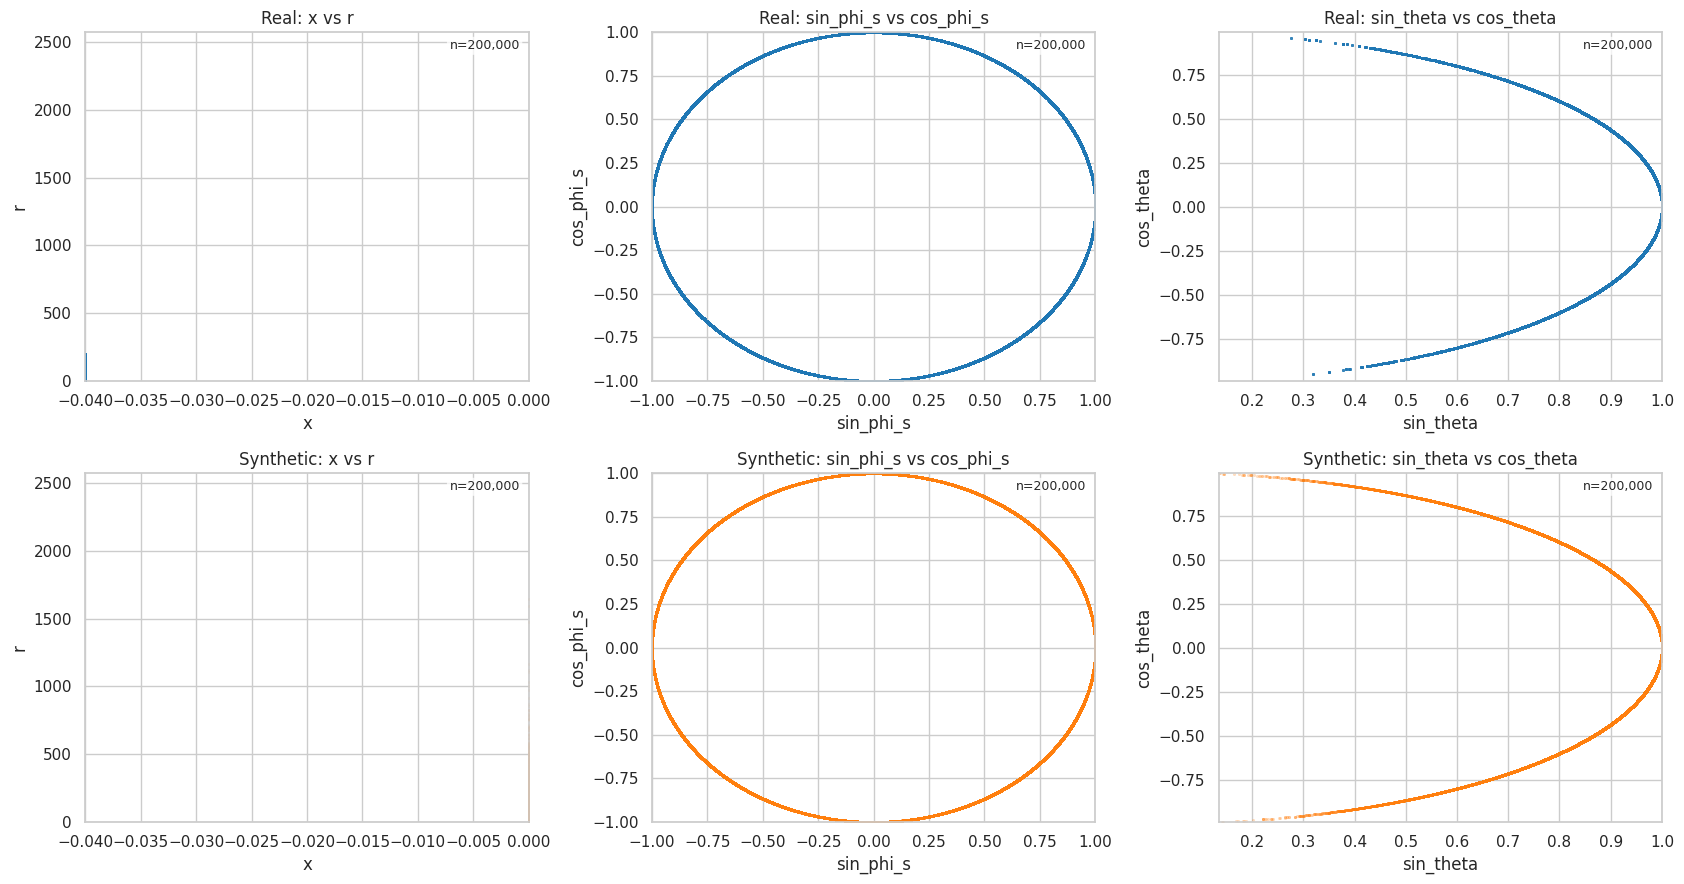

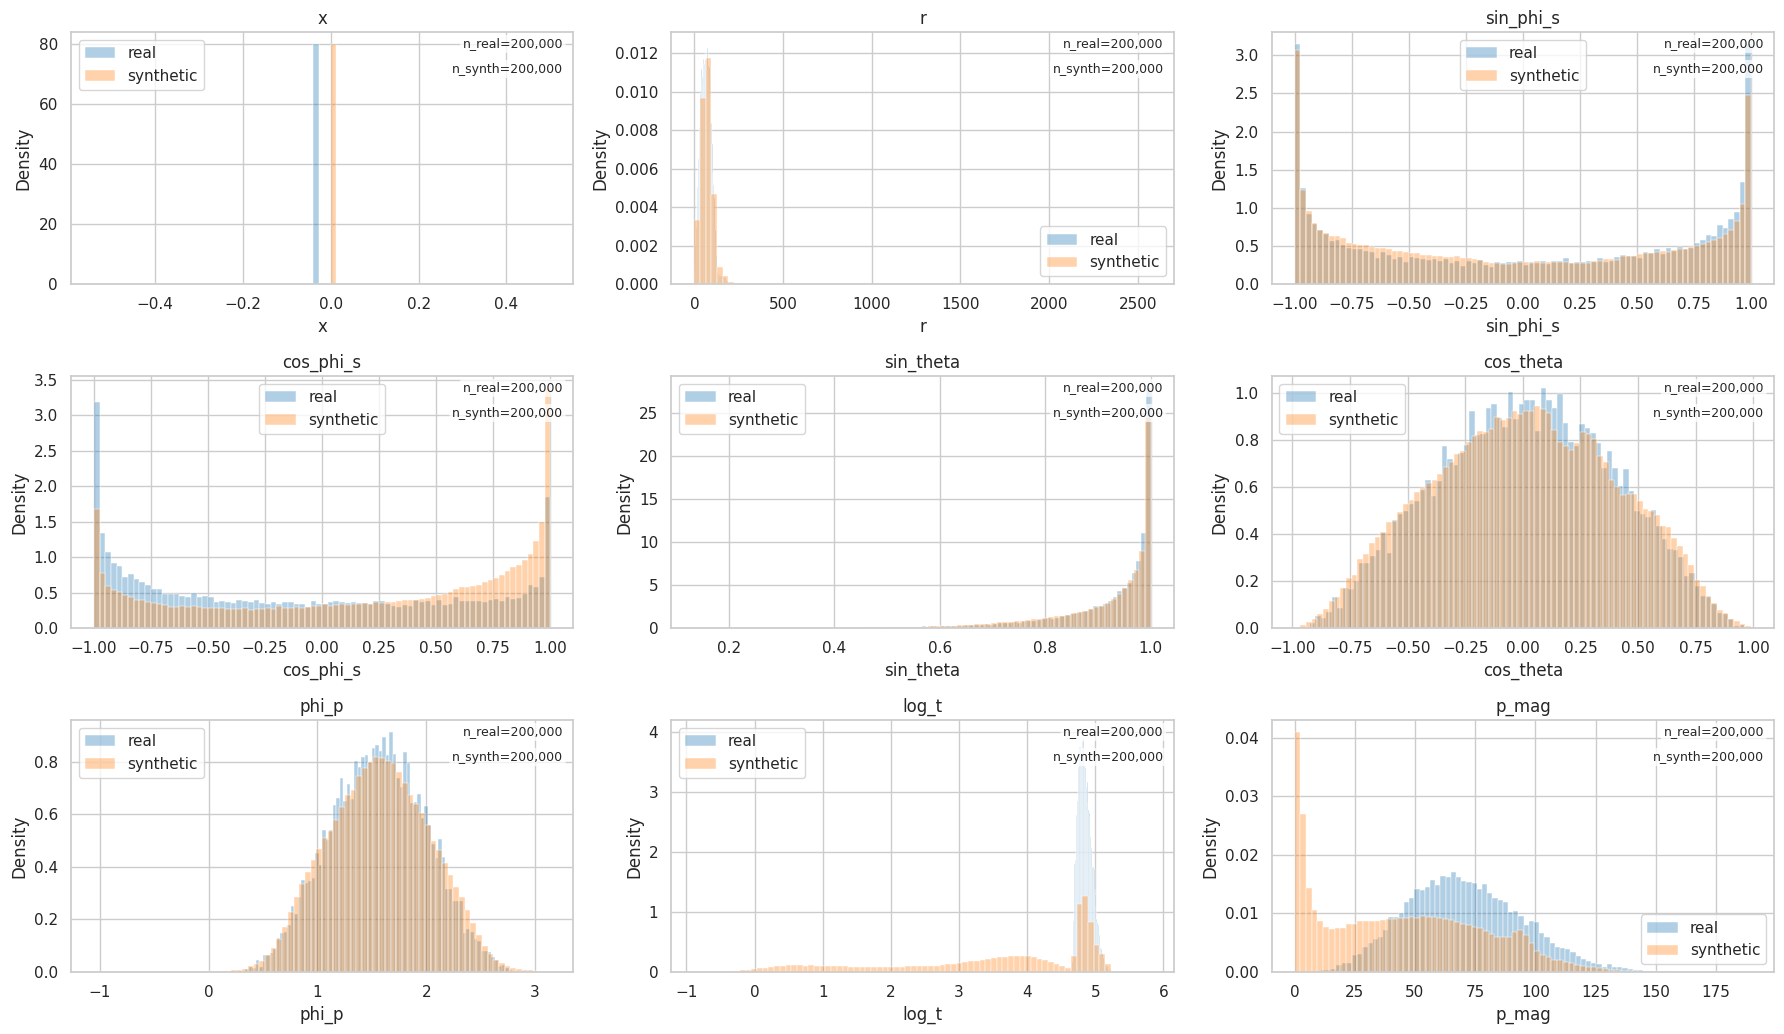

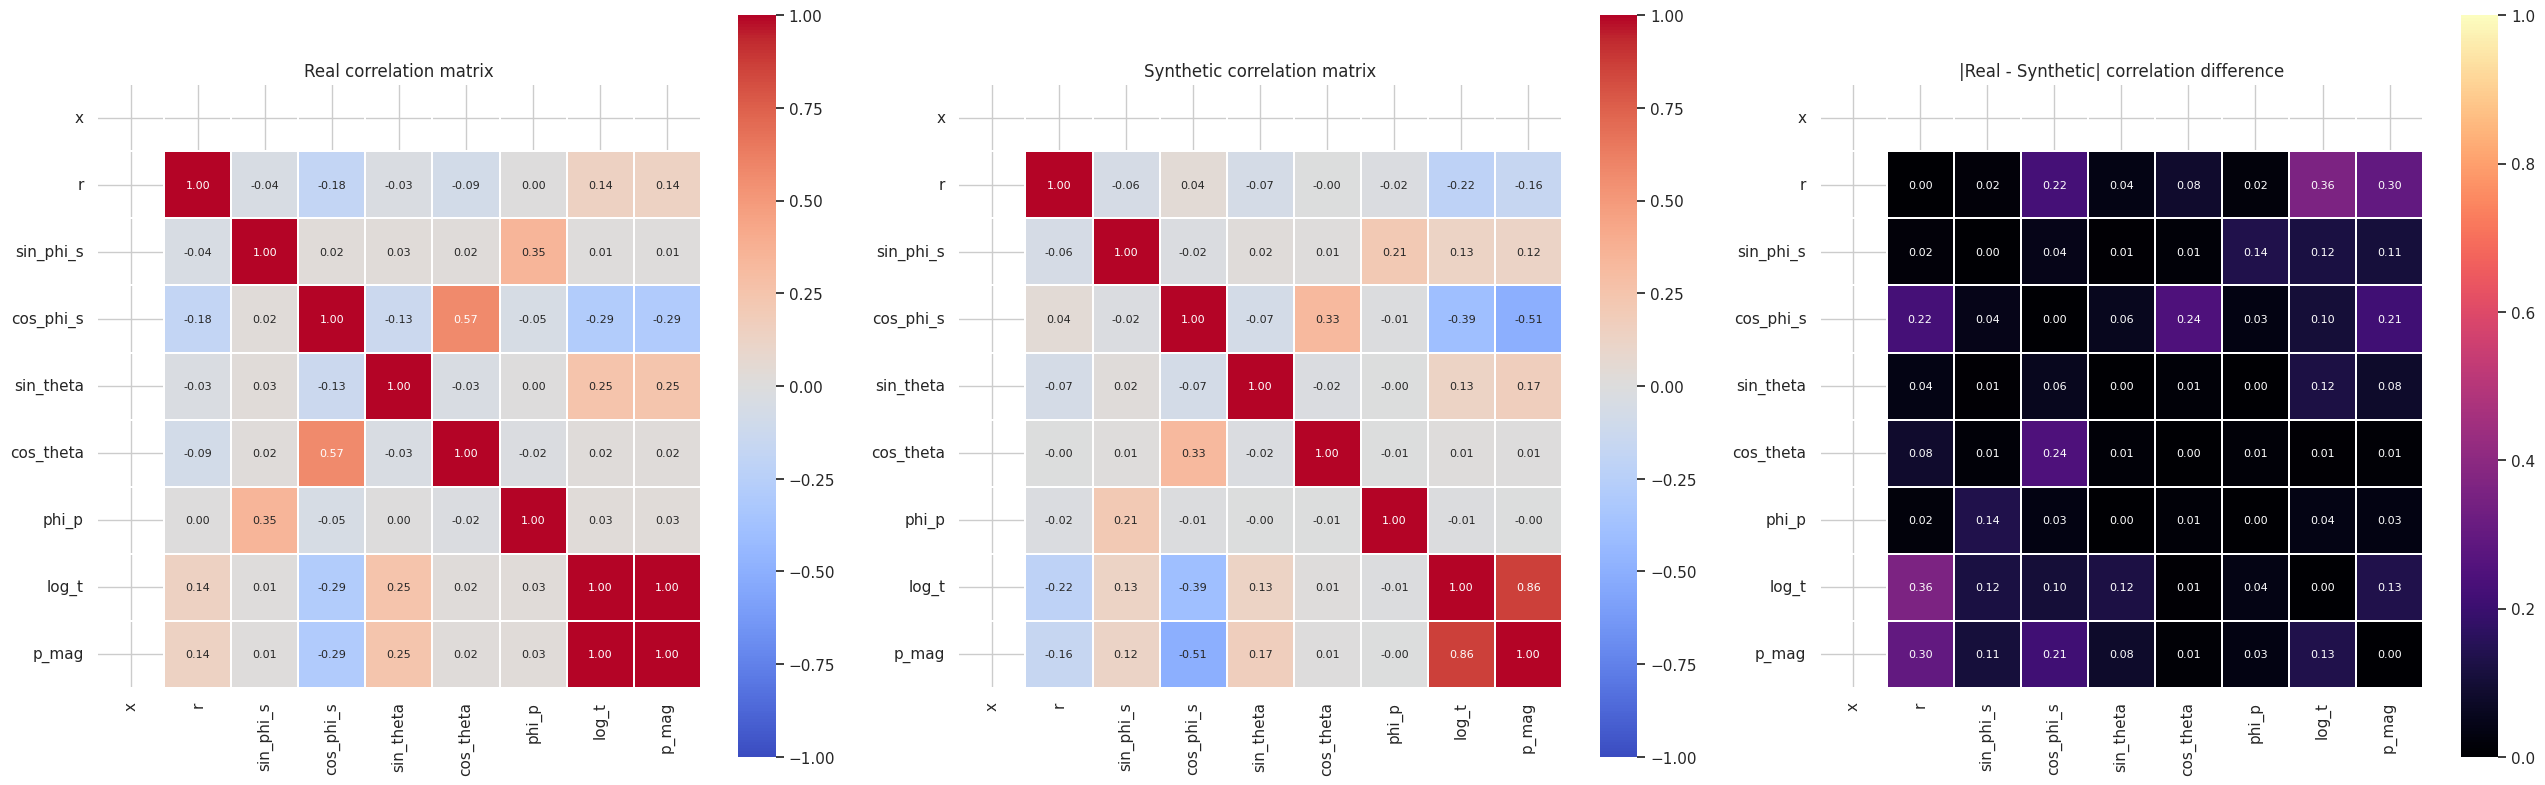

In [19]:
print_variable_means_before_plot(real_spill_df, synth_spill_df)
plot_3d_event_display(real_spill_df, synth_spill_df, max_points=200000)
plot_cylindrical_views(real_spill_df, synth_spill_df)
plot_cylindrical_marginals(real_spill_df, synth_spill_df)
plot_correlation_matrices(real_spill_df, synth_spill_df)

Count:    200,000
Unique:   1
Min:      -0.03999999999859938
Max:      -0.03999999999859938
Mean:     -0.03999999999859938
Std:      0.0

Value counts (top 20):
x
-0.04    200000
Name: count, dtype: int64


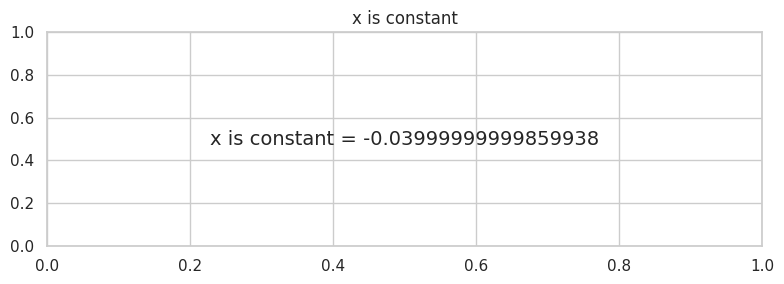

In [20]:
x_vals = real_spill_df['x'] if 'x' in real_spill_df.columns else None

if x_vals is None:
    print("'x' column not found in real_spill_df")
else:
    print(f"Count:    {len(x_vals):,}")
    print(f"Unique:   {x_vals.nunique():,}")
    print(f"Min:      {x_vals.min()}")
    print(f"Max:      {x_vals.max()}")
    print(f"Mean:     {x_vals.mean()}")
    print(f"Std:      {x_vals.std()}")
    print(f"\nValue counts (top 20):")
    print(x_vals.value_counts().head(20))
    
    plt.figure(figsize=(8, 3))
    if x_vals.nunique() > 1:
        sns.histplot(x_vals, bins=80, color='tab:blue')
        plt.title('Distribution of real x values')
    else:
        plt.text(0.5, 0.5, f'x is constant = {x_vals.iloc[0]}', ha='center', va='center', fontsize=14)
        plt.title('x is constant')
    plt.tight_layout()
    plt.show()